![alt text](<images/스크린샷 2026-08-11 151254.png>)

In [4]:
import pandas
import konlpy
import gensim

print(f"pandas version: {pandas.__version__}")
print(f"konlpy version: {konlpy.__version__}")
print(f"gensim version: {gensim.__version__}")

pandas version: 3.0.5
konlpy version: 0.6.0
gensim version: 4.3.2


#### 1) 데이터 준비와 확인

In [5]:
import pandas as pd

# 데이터를 읽어봅시다.
train_data = pd.read_table('~/work/sentiment_classification/data/ratings_train.txt')
test_data = pd.read_table('~/work/sentiment_classification/data/ratings_test.txt')

train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


#### 2) 데이터로더 구성

```
- 데이터의 중복 제거
- NaN 결측치 제거
- 한국어 토크나이저로 토큰화
- 불용어(Stopwords) 제거
- 사전word_to_index 구성
- 텍스트 스트링을 사전 인덱스 스트링으로 변환
- X_train, y_train, X_test, y_test, word_to_index 리턴
```

In [6]:
import MeCab
import numpy as np
from collections import Counter

# MeCab 형태소 분석기 준비
tokenizer = MeCab.Tagger()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

# 입력 문장을 형태소 어절로 분해하는 래퍼 함수
# MeCab.Tagger.parse() 는 문자열을 반환하므로, 결과를 줄 단위로 읽어
# 각 줄의 첫 컬럼(형태소)만 꺼내 리스트로 만듭니다.
def morphs(sentence):
    parsed = tokenizer.parse(sentence)
    result = []
    for line in parsed.splitlines():
        if line == 'EOS' or not line:
            continue
        fields = line.split('\t')
        if len(fields) > 1:
            result.append(fields[0])
    return result

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how='any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how='any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if word not in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if word not in stopwords] # 불용어 제거
        X_test.append(temp_X)

    # Vocabulary rebuild on actual token frequency.
    # Reserve the three special tokens used by the downstream encoding and padding utilities.
    # GoogleNews와 같은 사전 훈련 임베딩을 붙일 수 있도록
    # 모델의 입력 인덱스와 패딩 인덱스를 맞추는 특수 토큰을 예약합니다.
    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(num_words - 3)
    vocab = ['<PAD>', '<BOS>', '<UNK>'] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

In [7]:
index_to_word = {index:word for word, index in word_to_index.items()}

In [8]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수입니다.
# 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수입니다.
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

#### 3) 모델 구성을 위한 데이터 분석 및 가공

```
- 데이터셋 내 문장 길이 분포
- 적절한 최대 문장 길이 지정
- torch.nn.utils.rnn.pad_sequence 을 활용한 패딩 추가
```

X_train 문장 길이 요약
count    146182.000000
mean         15.981708
std          12.824782
min           0.000000
25%           7.000000
50%          12.000000
75%          19.000000
max         116.000000
dtype: float64

X_train 문장 길이 95% 분위수: 47.0
X_train 문장 길이 최대값: 116
X_train 문장 길이 최소값: 0


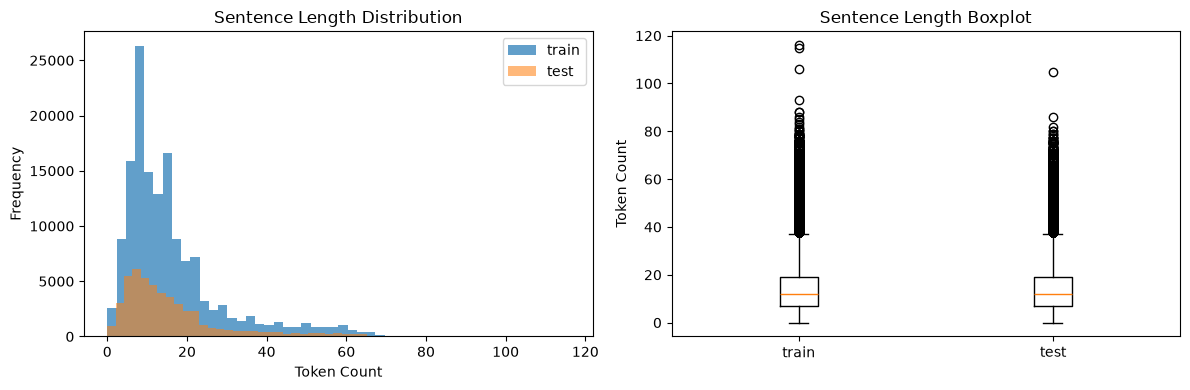

선택한 max_len = 47
X_train_padded shape: torch.Size([146182, 47])
X_test_padded shape: torch.Size([49157, 47])


In [9]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# 3) 모델 구성을 위한 데이터 분석 및 가공
# 1. 데이터셋 내 문장 길이 분포 확인
train_lengths = [len(seq) for seq in X_train]
test_lengths = [len(seq) for seq in X_test]

length_summary = pd.Series(train_lengths).describe()
print('X_train 문장 길이 요약')
print(length_summary)
print()
print('X_train 문장 길이 95% 분위수:', np.percentile(train_lengths, 95))
print('X_train 문장 길이 최대값:', max(train_lengths))
print('X_train 문장 길이 최소값:', min(train_lengths))

# 문장 길이 분포 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(train_lengths, bins=50, alpha=0.7, label='train')
plt.hist(test_lengths, bins=50, alpha=0.55, label='test')
plt.title('Sentence Length Distribution')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([train_lengths, test_lengths], tick_labels=['train', 'test'])
plt.title('Sentence Length Boxplot')
plt.ylabel('Token Count')
plt.tight_layout()
plt.show()

# 2. 적절한 최대 문장 길이 지정
# 데이터의 95% 분위수로 max_len을 설정해 긴 문장에 대한 과도한 패딩을 줄입니다.
max_len = int(np.percentile(train_lengths, 95))
if max_len < 1:
    max_len = 1

print(f'선택한 max_len = {max_len}')

# 3. torch.nn.utils.rnn.pad_sequence 를 활용한 패딩
# 각 문장가 max_len을 넘는 경우 잘라서 길이를 맞추고, 그 뒤 패딩을 추가합니다.
# pad_idx는 사전에서 <PAD> 토큰을 찾거나 없으면 0을 사용합니다.
pad_idx = word_to_index.get('<PAD>', 0)

# 긴 문장을 max_len 기준으로 자른 뒤 Tensor로 변환
X_train_tensors = [torch.tensor(seq[:max_len], dtype=torch.long) for seq in X_train]
X_test_tensors = [torch.tensor(seq[:max_len], dtype=torch.long) for seq in X_test]

# pad_sequence로 같은 길이의 배치 텐서 생성
X_train_padded = torch.nn.utils.rnn.pad_sequence(
    X_train_tensors,
    batch_first=True,
    padding_value=pad_idx
)

X_test_padded = torch.nn.utils.rnn.pad_sequence(
    X_test_tensors,
    batch_first=True,
    padding_value=pad_idx
)

print('X_train_padded shape:', X_train_padded.shape)
print('X_test_padded shape:', X_test_padded.shape)

#### 4) 모델 구성 및 validation set 구성

```
모델은 3가지 이상 다양하게 구성하여 실험해 보세요.
```

In [10]:
# RNN 모델 구성
import torch.nn as nn

class Model_RNN(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_RNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 8, batch_first=True)   # 가장 널리 쓰이는 RNN인 LSTM 레이어를 사용하였습니다. 이때 LSTM state 벡터의 차원수는 8로 하였습니다. (변경 가능)
        self.fc1 = nn.Linear(8, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)    # 최종 출력은 긍정/부정을 나타내는 1dim 입니다.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (h_n, c_n) = self.lstm(x)
        x = h_n[-1]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

vocab_size = 10   # 어휘 사전의 크기입니다(10개의 단어)
word_vector_dim = 4   # 단어 하나를 표현하는 임베딩 벡터의 차원수입니다.
model = Model_RNN(vocab_size, word_vector_dim)

print(model)

Model_RNN(
  (embedding): Embedding(10, 4)
  (lstm): LSTM(4, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [11]:
# 1D CNN 모델 구성
class Model_1DCNN(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_1DCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.conv1 = nn.Conv1d(word_vector_dim, 16, kernel_size=7)
        self.conv2 = nn.Conv1d(16, 16, kernel_size=7)
        self.pool = nn.MaxPool1d(5)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(16, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)    # 최종 출력은 긍정/부정을 나타내는 1dim 입니다.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.global_max_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

vocab_size = 10    # 어휘 사전의 크기입니다(10개의 단어)
word_vector_dim = 4   # 단어 하나를 표현하는 임베딩 벡터의 차원 수입니다.
model = Model_1DCNN(vocab_size, word_vector_dim)

print(model)

Model_1DCNN(
  (embedding): Embedding(10, 4)
  (conv1): Conv1d(4, 16, kernel_size=(7,), stride=(1,))
  (conv2): Conv1d(16, 16, kernel_size=(7,), stride=(1,))
  (pool): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (global_max_pooling): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=16, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [12]:
# CNN 모델 구성 - GlobalMaxPooling1D() 레이어 하나만 사용
class Model_CNN_GlobalMaxPooling(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_CNN_GlobalMaxPooling, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(word_vector_dim, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)    # 최종 출력은 긍정/부정을 나타내는 1dim 입니다.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.global_max_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

vocab_size = 10   # 어휘 사전의 크기입니다(10개의 단어)
word_vector_dim = 4   # 단어 하나를 표현하는 임베딩 벡터의 차원 수입니다.
model = Model_CNN_GlobalMaxPooling(vocab_size, word_vector_dim)

print(model)

Model_CNN_GlobalMaxPooling(
  (embedding): Embedding(10, 4)
  (global_max_pooling): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [44]:
# RNN 모델 구성 - LSTM 레이어를 사용
import torch
import torch.nn as nn
import torch.nn.functional as F

vocab_size = 10000    # 어휘 사전의 크기입니다(10,000개의 단어)
word_vector_dim = 16  # 워드 벡터의 차원 수 (변경 가능한 하이퍼파라미터)

# model 설계 - 딥러닝 모델 코드를 직접 작성해 주세요.
class SentimentModel_RNN(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(SentimentModel_RNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 8, batch_first=True)
        self.fc1 = nn.Linear(8, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.embedding(x)
        x, (hn, cn) = self.lstm(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = SentimentModel_RNN(vocab_size, word_vector_dim)
print(model)

SentimentModel_RNN(
  (embedding): Embedding(10000, 16)
  (lstm): LSTM(16, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


#### 5) 모델 훈련 개시

In [14]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import os
import numpy as np

CONFIG = {
    'epochs': 30,
    'lr': 0.001,
    'batch_size': 512,
    'val_ratio': 0.2,
    'random_state': 42,
    'word_vector_dim': 16,
    'pretrained_limit': 100000,
    'google_w2v_path': r'C:\Users\eaglesjo\work\sentiment_classification\data\GoogleNews-vectors-negative300.bin.gz',
}

# 입력 데이터는 앞 단계에서 max_len 기준으로 패딩된 X_train_padded / X_test_padded 를 사용합니다.
X_train_tensor = X_train_padded.clone().detach().to(torch.long)
X_test_tensor = X_test_padded.clone().detach().to(torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# validation set 구성
train_idx, val_idx = train_test_split(
    np.arange(len(y_train_tensor)),
    test_size=CONFIG['val_ratio'],
    random_state=CONFIG['random_state'],
    stratify=y_train
)

train_dataset = TensorDataset(X_train_tensor[train_idx], y_train_tensor[train_idx])
val_dataset = TensorDataset(X_train_tensor[val_idx], y_train_tensor[val_idx])
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

# 4개 모델을 하나의 딕셔너리로 묶어 순회 실험을 수행합니다.
vocab_size = len(word_to_index)
word_vector_dim = CONFIG['word_vector_dim']

loss_fn = nn.BCELoss()
# 정의한 4개 모델 클래스들을 등록합니다.
model_registry = {
    'Model_RNN': Model_RNN,
    'Model_1DCNN': Model_1DCNN,
    'Model_CNN_GlobalMaxPooling': Model_CNN_GlobalMaxPooling,
    'SentimentModel_RNN': SentimentModel_RNN,
}

google_path = CONFIG['google_w2v_path']

pretrained_wv = None
if os.path.exists(google_path):
    from gensim.models import KeyedVectors
    pretrained_wv = KeyedVectors.load_word2vec_format(google_path, binary=True, limit=CONFIG['pretrained_limit'])

training_history = {}

# 4개 모델을 각각 학습합니다.
for model_name, model_cls in model_registry.items():
    model = model_cls(vocab_size, word_vector_dim)

    if pretrained_wv is not None:
        embedding_matrix = np.zeros((vocab_size, word_vector_dim), dtype=np.float32)
        for word, idx in word_to_index.items():
            if word in pretrained_wv:
                emb = pretrained_wv[word]
                if emb.shape[0] >= word_vector_dim:
                    embedding_matrix[idx] = emb[:word_vector_dim]
                else:
                    embedding_matrix[idx] = np.random.uniform(-0.25, 0.25, word_vector_dim)
            else:
                embedding_matrix[idx] = np.random.uniform(-0.25, 0.25, word_vector_dim)

        with torch.no_grad():
            model.embedding.weight.copy_(torch.tensor(embedding_matrix))
            model.embedding.weight[pad_idx] = 0.0

    optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])
    epochs = CONFIG['epochs']
    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accs': [],
        'val_accs': [],
        'model': model,
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels.squeeze())
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = (outputs.squeeze() >= 0.5).long()
            correct += (preds == labels.squeeze().long()).sum().item()
            total += labels.size(0)

        avg_train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        history['train_losses'].append(avg_train_loss)
        history['train_accs'].append(train_acc)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = loss_fn(outputs.squeeze(), labels.squeeze())
                val_loss += loss.item()

                preds = (outputs.squeeze() >= 0.5).long()
                val_correct += (preds == labels.squeeze().long()).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        history['val_losses'].append(val_loss)
        history['val_accs'].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {history['train_losses'][-1]:.4f}, Train Accuracy: {history['train_accs'][-1]:.4f} - "
              f"Validation Loss: {history['val_losses'][-1]:.4f}, Validation Accuracy: {history['val_accs'][-1]:.4f}")

    training_history[model_name] = history

print('training finished')

[Model_RNN] Epoch 1/30 - Train Loss: 0.6949, Train Accuracy: 0.4987 - Validation Loss: 0.6931, Validation Accuracy: 0.5009
[Model_RNN] Epoch 2/30 - Train Loss: 0.6926, Train Accuracy: 0.5100 - Validation Loss: 0.6901, Validation Accuracy: 0.5233
[Model_RNN] Epoch 3/30 - Train Loss: 0.5658, Train Accuracy: 0.7463 - Validation Loss: 0.5267, Validation Accuracy: 0.7761
[Model_RNN] Epoch 4/30 - Train Loss: 0.5404, Train Accuracy: 0.7587 - Validation Loss: 0.5466, Validation Accuracy: 0.7695
[Model_RNN] Epoch 5/30 - Train Loss: 0.5341, Train Accuracy: 0.7729 - Validation Loss: 0.5467, Validation Accuracy: 0.7591
[Model_RNN] Epoch 6/30 - Train Loss: 0.5448, Train Accuracy: 0.7571 - Validation Loss: 0.5533, Validation Accuracy: 0.7367
[Model_RNN] Epoch 7/30 - Train Loss: 0.6681, Train Accuracy: 0.5527 - Validation Loss: 0.6887, Validation Accuracy: 0.5032
[Model_RNN] Epoch 8/30 - Train Loss: 0.6855, Train Accuracy: 0.5192 - Validation Loss: 0.6824, Validation Accuracy: 0.5285
[Model_RNN] Epoc

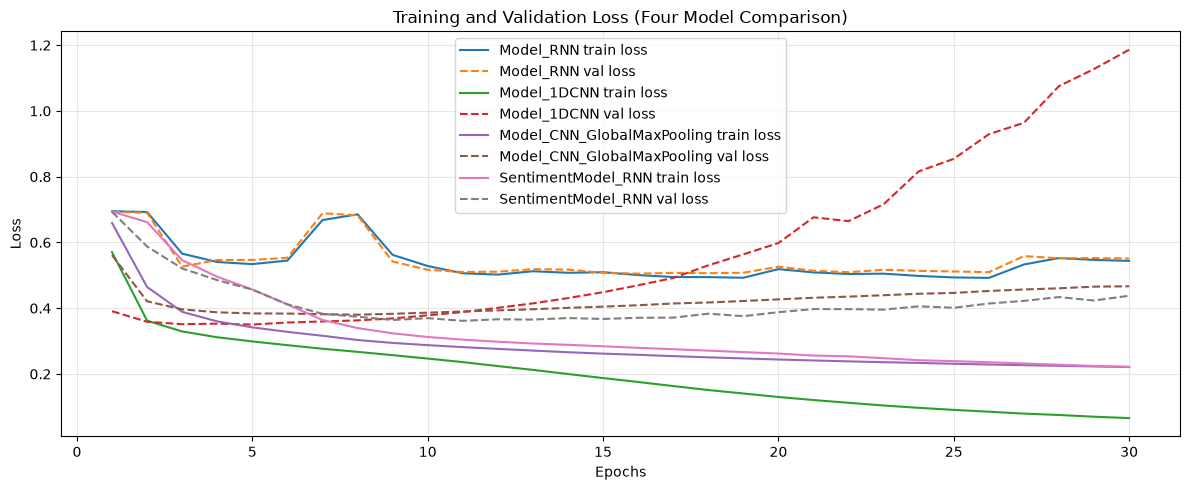

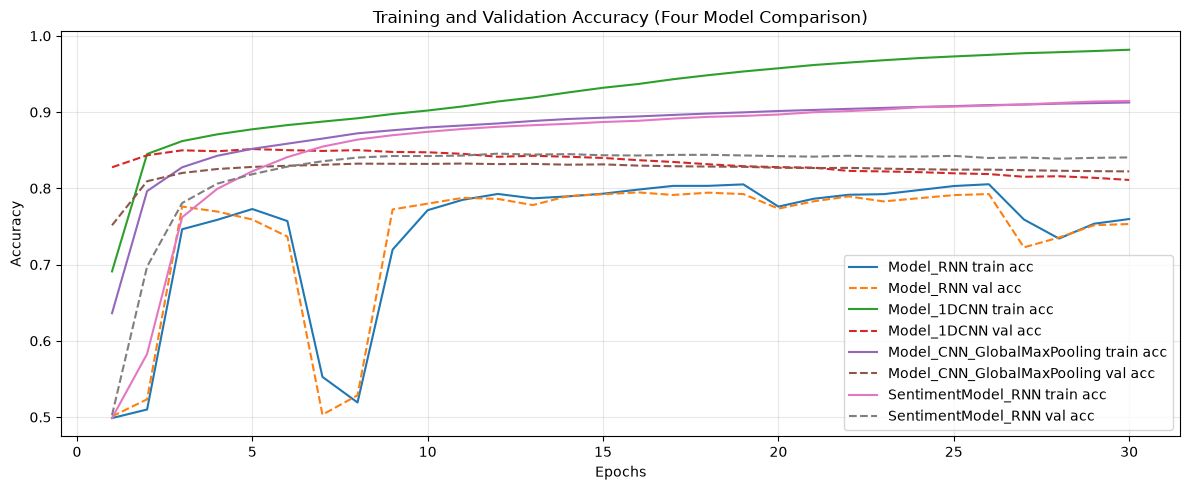

In [15]:
import matplotlib.pyplot as plt

epochs_range = range(1, CONFIG['epochs'] + 1)

plt.figure(figsize=(12, 5))
for name, history in training_history.items():
    plt.plot(epochs_range, history['train_losses'], label=f'{name} train loss')
    plt.plot(epochs_range, history['val_losses'], linestyle='--', label=f'{name} val loss')

plt.title('Training and Validation Loss (Four Model Comparison)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for name, history in training_history.items():
    plt.plot(epochs_range, history['train_accs'], label=f'{name} train acc')
    plt.plot(epochs_range, history['val_accs'], linestyle='--', label=f'{name} val acc')

plt.title('Training and Validation Accuracy (Four Model Comparison)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 7) 학습된 Embedding 레이어 분석

--- Model_RNN embedding layer 분석 ---
embedding shape: (10000, 16)


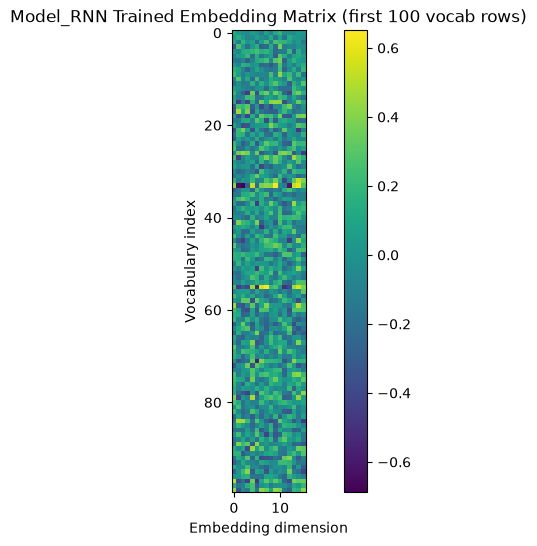

[Model_RNN] 자체학습 임베딩 유사단어 검색: 재미
[('사기극', 0.7597578763961792), ('발상', 0.7369765043258667), ('마당', 0.7345271110534668), ('이영활', 0.7076915502548218), ('사만다', 0.6979049444198608)]
[Model_RNN] GoogleNews 사전학습 유사단어 검색: movie
[('film', 0.8676770329475403), ('movies', 0.8013108372688293), ('films', 0.7363011837005615), ('Movie', 0.6693680286407471), ('horror_flick', 0.6577848792076111)]

--- Model_1DCNN embedding layer 분석 ---
embedding shape: (10000, 16)


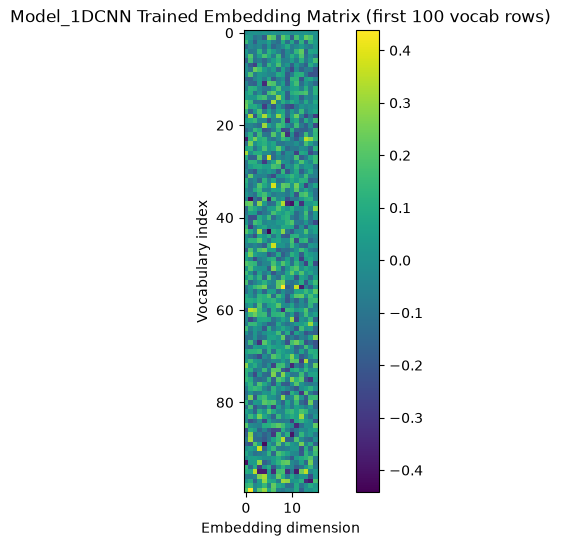

[Model_1DCNN] 자체학습 임베딩 유사단어 검색: 재미
[('그래도', 0.827383279800415), ('연정훈', 0.7093899846076965), ('열광', 0.6992442607879639), ('능력', 0.6971232891082764), ('배꼽', 0.6955308318138123)]
[Model_1DCNN] GoogleNews 사전학습 유사단어 검색: movie
[('film', 0.8676770329475403), ('movies', 0.8013108372688293), ('films', 0.7363011837005615), ('Movie', 0.6693680286407471), ('horror_flick', 0.6577848792076111)]

--- Model_CNN_GlobalMaxPooling embedding layer 분석 ---
embedding shape: (10000, 16)


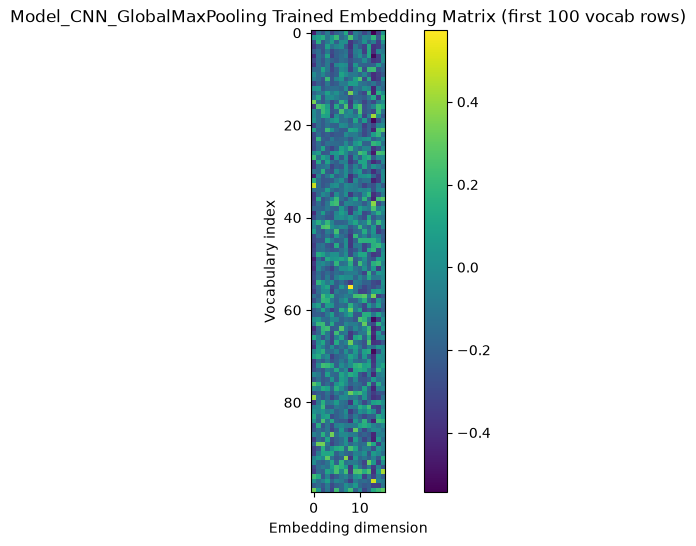

[Model_CNN_GlobalMaxPooling] 자체학습 임베딩 유사단어 검색: 재미
[('아무튼', 0.7959681749343872), ('수박', 0.7826003432273865), ('선교', 0.775091290473938), ('다양', 0.7594085335731506), ('뚱', 0.7480448484420776)]
[Model_CNN_GlobalMaxPooling] GoogleNews 사전학습 유사단어 검색: movie
[('film', 0.8676770329475403), ('movies', 0.8013108372688293), ('films', 0.7363011837005615), ('Movie', 0.6693680286407471), ('horror_flick', 0.6577848792076111)]

--- SentimentModel_RNN embedding layer 분석 ---
embedding shape: (10000, 16)


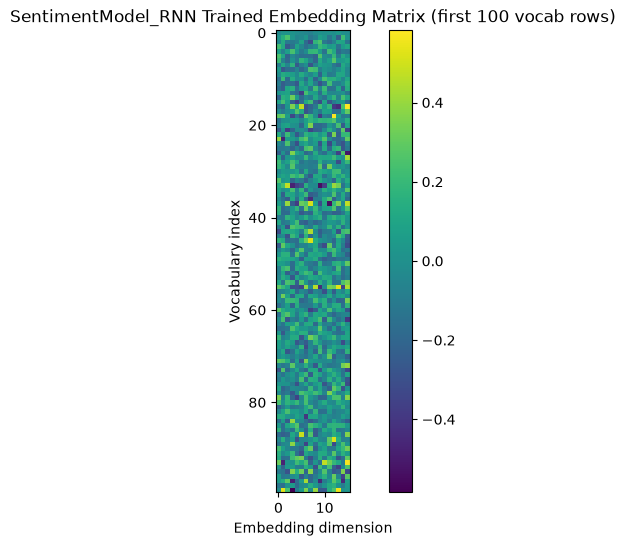

[SentimentModel_RNN] 자체학습 임베딩 유사단어 검색: 재미
[('폭발', 0.8464218378067017), ('잼', 0.8006706237792969), ('정말', 0.7937191128730774), ('긴장감', 0.7839059233665466), ('가정', 0.7833007574081421)]
[SentimentModel_RNN] GoogleNews 사전학습 유사단어 검색: movie
[('film', 0.8676770329475403), ('movies', 0.8013108372688293), ('films', 0.7363011837005615), ('Movie', 0.6693680286407471), ('horror_flick', 0.6577848792076111)]



In [16]:
from gensim.models import KeyedVectors
import os

# 사전학습 임베딩 파일이 있으면 로드
google_path = CONFIG['google_w2v_path']
pretrained_wv = None
if os.path.exists(google_path):
    pretrained_wv = KeyedVectors.load_word2vec_format(google_path, binary=True, limit=100000)

for model_name, history in training_history.items():
    selected_model = history['model']
    embedding_weights = selected_model.embedding.weight.detach().cpu().numpy()

    print(f'--- {model_name} embedding layer 분석 ---')
    print('embedding shape:', embedding_weights.shape)

    # 자체학습 임베딩을 gensim KeyedVectors로 재구성
    ordered_vocab = [index_to_word[i] for i in range(len(index_to_word))]
    self_trained_wv = KeyedVectors(vector_size=embedding_weights.shape[1])
    self_trained_wv.add_vectors(ordered_vocab, embedding_weights)

    # 임베딩 행렬 일부 시각화
    plt.figure(figsize=(10, 6))
    plt.imshow(embedding_weights[:100], cmap='viridis')
    plt.colorbar()
    plt.title(f'{model_name} Trained Embedding Matrix (first 100 vocab rows)')
    plt.xlabel('Embedding dimension')
    plt.ylabel('Vocabulary index')
    plt.show()

    query_word = '재미'
    print(f'[{model_name}] 자체학습 임베딩 유사단어 검색: {query_word}')
    try:
        self_sim = self_trained_wv.most_similar(query_word, topn=5)
        print(self_sim)
    except Exception as e:
        print(f'자체학습 임베딩에서 {query_word} 유사단어를 찾지 못했습니다: {e}')

    if pretrained_wv is not None:
        print(f'[{model_name}] GoogleNews 사전학습 유사단어 검색: movie')
        try:
            google_sim = pretrained_wv.most_similar('movie', topn=5)
            print(google_sim)
        except Exception as e:
            print('GoogleNews 유사단어 검색 실패:', e)
    else:
        print('GoogleNews 파일을 찾지 못해서 사전학습 유사단어 비교를 생략합니다.')

    print()

#### 8) 한국어 Word2Vec 임베딩 활용하여 성능 개선

```
- 한국어 Word2Vec은 /data 폴더 안에 있는 word2vec_ko.model을 활용하세요.
- 한국어 Word2Vec을 활용할 때는 load_word2vec_format() 형태가 아닌 load() 형태로 모델을 불러와주세요.
- 또한 모델을 활용할 때에는 아래 예시와 같이 .wv를 붙여서 활용합니다

# 예시 코드
from gensim.models.keyedvectors import Word2VecKeyedVectors
word_vectors = Word2VecKeyedVectors.load(word2vec_file_path)
vector = word_vectors.wv[‘끝’]
```

In [45]:
import pandas as pd
import os

save_path = os.path.expanduser("~/work/sentiment_classification/data/nsmc_corpus.txt")
df = pd.read_csv(os.path.expanduser("~/work/sentiment_classification/data/ratings_train.txt"), sep="\t")

with open(save_path, "w", encoding="utf-8") as f:
    for text in df["document"].dropna():
        f.write(text.replace("\n", " ") + "\n")

print("nsmc_corpus.txt 생성 완료!")

nsmc_corpus.txt 생성 완료!


In [46]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

# NSMC 말뭉치 로드
sentences = LineSentence(save_path)

# 감성 분석용 Word2Vec 학습
model = Word2Vec(
            sentences,
            vector_size=200,   # 감성 분석에 가장 안정적
            window=5,
            min_count=3,       # 감성 단어는 빈도가 낮아 낮게 설정
            workers=4,
            sg=1,              # skip-gram → 감성 표현에 강함
            negative=10,
            epochs=10
        )

# 모델 저장
model.save(os.path.expanduser("~/work/sentiment_classification/data/word2vec_ko.model"))
print("word2vec_ko.model 생성 완료!")

word2vec_ko.model 생성 완료!


In [48]:
from gensim.models import Word2Vec

model = Word2Vec.load(os.path.expanduser("~/work/sentiment_classification/data/word2vec_ko.model"))

print(model.wv.most_similar("재밌다"))
print(model.wv.most_similar("최고"))
print(model.wv.most_similar("별로"))
print(model.wv.most_similar("지루하다"))

[('재밌네', 0.8323234915733337), ('재밌음', 0.800772488117218), ('재미있다', 0.7980437874794006), ('재미있음', 0.7957473993301392), ('스릴있고', 0.7926532626152039), ('재밋음', 0.7890943884849548), ('재밌다ㅋㅋㅋ', 0.7886028289794922), ('!!!!!!', 0.7873762845993042), ('재밋어요', 0.7857915163040161), ('졸잼', 0.785128116607666)]
[('단연', 0.7109336256980896), ('최고.', 0.7027475833892822), ('전성기', 0.6998717784881592), ('쵝오', 0.6889290809631348), ('최고다', 0.6826059818267822), ('3대', 0.6824752688407898), ('최고..', 0.6777672171592712), ('레전드', 0.677729606628418), ('당연', 0.6719876527786255), ('대부', 0.6712640523910522)]
[('그다지', 0.7195450067520142), ('그닥', 0.6926464438438416), ('좋아하지', 0.6499989032745361), ('않았는데', 0.6146059632301331), ('무섭지도', 0.6102733612060547), ('않고...', 0.6036311388015747), ('웃기지도', 0.6013247966766357), ('그닥...', 0.6007391214370728), ('감동적이지도', 0.5963992476463318), ('궁금하지', 0.5942273139953613)]
[('늘어지고', 0.8116089105606079), ('지루하고..', 0.7994377017021179), ('지루한건', 0.7906786203384399), ('빈약하다.', 0.778959810

In [49]:
from gensim.models.keyedvectors import Word2VecKeyedVectors
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn as nn

word2vec_file_path = '~/work/sentiment_classification/data/word2vec_ko.model'
if not os.path.exists(word2vec_file_path):
    word2vec_file_path = os.path.join(os.path.expanduser('~'), 'work', 'sentiment_classification', 'data', 'word2vec_ko.model')
    print(f'Fallback word2vec_file_path: {word2vec_file_path}')

ko_word_vectors = Word2VecKeyedVectors.load(word2vec_file_path)
ko_wv = ko_word_vectors.wv if hasattr(ko_word_vectors, 'wv') else ko_word_vectors
print('Korean Word2Vec loaded:', ko_wv.vector_size, 'dims,', len(ko_wv.index_to_key), 'words')
print('Example vector for 끝:', ko_wv['끝'][:5])

vocab_size = len(word_to_index)
word_vector_dim = CONFIG['word_vector_dim']
ko_vector_dim = ko_wv.vector_size

embedding_matrix = np.random.uniform(-0.25, 0.25, size=(vocab_size, word_vector_dim)).astype(np.float32)
for word, idx in word_to_index.items():
    if word in ko_wv:
        if ko_vector_dim >= word_vector_dim:
            embedding_matrix[idx] = ko_wv[word][:word_vector_dim]
        else:
            emb = np.zeros(word_vector_dim, dtype=np.float32)
            emb[:ko_vector_dim] = ko_wv[word]
            embedding_matrix[idx] = emb

pad_idx = word_to_index.get('<PAD>', 0)
if pad_idx < vocab_size:
    embedding_matrix[pad_idx] = np.zeros(word_vector_dim, dtype=np.float32)

Ko_Word2Vec = SentimentModel_RNN(vocab_size, word_vector_dim)

with torch.no_grad():
    Ko_Word2Vec.embedding.weight.copy_(torch.tensor(embedding_matrix))
    Ko_Word2Vec.embedding.weight[pad_idx] = 0.0

print('한국어 Word2Vec 임베딩 초기화 완료')
print(Ko_Word2Vec)

Fallback word2vec_file_path: C:\Users\eaglesjo\work\sentiment_classification\data\word2vec_ko.model
Korean Word2Vec loaded: 200 dims, 42635 words
Example vector for 끝: [ 0.19346052 -0.22147262 -0.30111217  0.00884052  0.37039334]
한국어 Word2Vec 임베딩 초기화 완료
SentimentModel_RNN(
  (embedding): Embedding(10000, 16)
  (lstm): LSTM(16, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


In [50]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(Ko_Word2Vec.parameters(), lr=CONFIG['lr'])
epochs = CONFIG['epochs']

for epoch in range(1, epochs + 1):
    Ko_Word2Vec.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = Ko_Word2Vec(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        preds = (outputs >= 0.5).long()
        train_correct += (preds == labels.long()).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    Ko_Word2Vec.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = Ko_Word2Vec(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).long()
            val_correct += (preds == labels.long()).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f'Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f} - Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}')

Epoch 1/30 - Train Loss: 0.7098, Train Accuracy: 0.5000 - Validation Loss: 0.6940, Validation Accuracy: 0.5017
Epoch 2/30 - Train Loss: 0.6935, Train Accuracy: 0.5017 - Validation Loss: 0.6933, Validation Accuracy: 0.5017
Epoch 3/30 - Train Loss: 0.6928, Train Accuracy: 0.5018 - Validation Loss: 0.6920, Validation Accuracy: 0.5031
Epoch 4/30 - Train Loss: 0.6903, Train Accuracy: 0.5113 - Validation Loss: 0.6889, Validation Accuracy: 0.5158
Epoch 5/30 - Train Loss: 0.6375, Train Accuracy: 0.6825 - Validation Loss: 0.6876, Validation Accuracy: 0.5163
Epoch 6/30 - Train Loss: 0.6686, Train Accuracy: 0.5798 - Validation Loss: 0.6887, Validation Accuracy: 0.5127
Epoch 7/30 - Train Loss: 0.6284, Train Accuracy: 0.7027 - Validation Loss: 0.6202, Validation Accuracy: 0.7528
Epoch 8/30 - Train Loss: 0.6187, Train Accuracy: 0.7560 - Validation Loss: 0.6194, Validation Accuracy: 0.7562
Epoch 9/30 - Train Loss: 0.6281, Train Accuracy: 0.7577 - Validation Loss: 0.6719, Validation Accuracy: 0.7117
E

In [51]:
# 테스트 평가
Ko_Word2Vec.eval()
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = Ko_Word2Vec(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        preds = (outputs >= 0.5).long()
        test_correct += (preds == labels.long()).sum().item()
        test_total += labels.size(0)

if test_total > 0:
    test_loss /= test_total
    test_acc = test_correct / test_total
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
else:
    print('Test dataset이 비어 있습니다.')

Test Loss: 0.6106, Test Accuracy: 0.7652


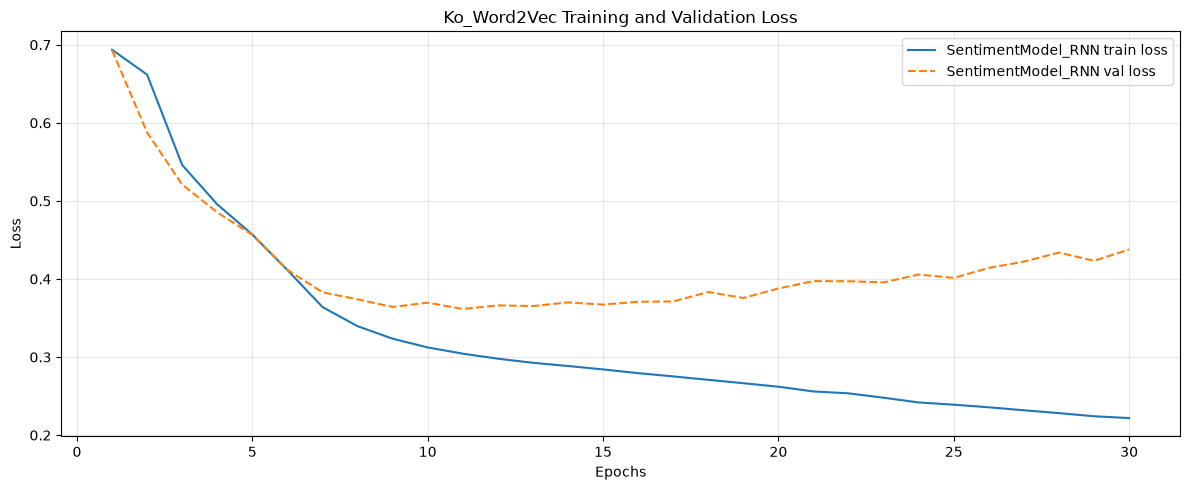

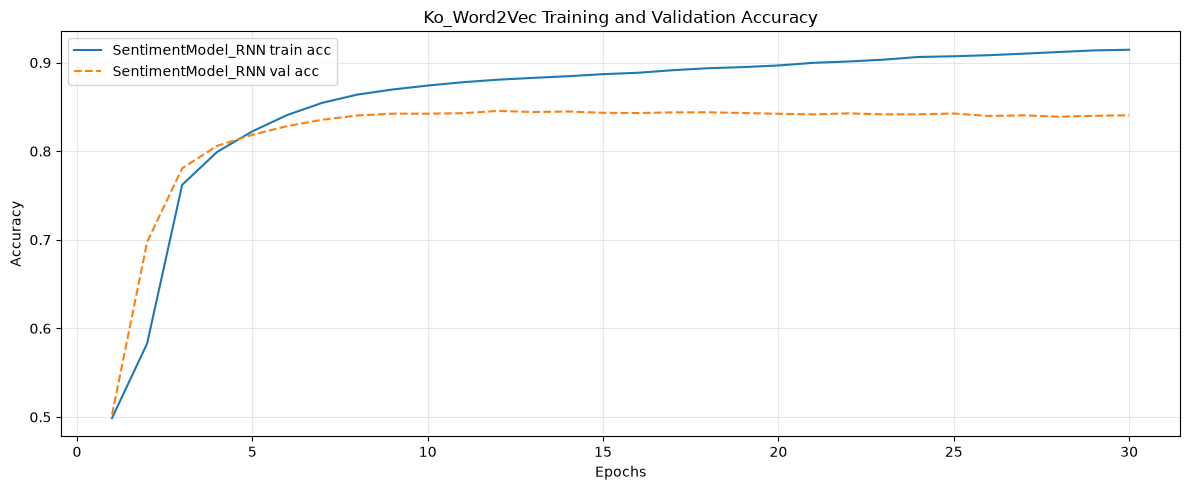

In [52]:
import matplotlib.pyplot as plt

epochs_range = range(1, CONFIG['epochs'] + 1)

plt.figure(figsize=(12, 5))
plt.plot(epochs_range, history['train_losses'], label=f'{name} train loss')
plt.plot(epochs_range, history['val_losses'], linestyle='--', label=f'{name} val loss')

plt.title('Ko_Word2Vec Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(epochs_range, history['train_accs'], label=f'{name} train acc')
plt.plot(epochs_range, history['val_accs'], linestyle='--', label=f'{name} val acc')

plt.title('Ko_Word2Vec Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--- Ko_Word2Vec embedding layer 분석 ---
embedding shape: (10000, 16)


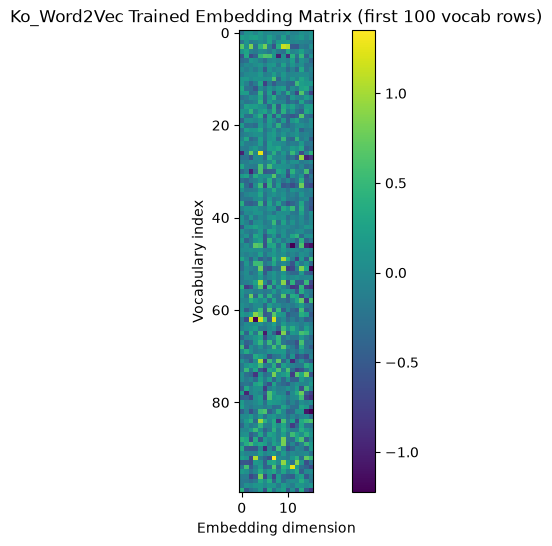

Ko_Word2Vec 자체학습 임베딩 유사단어 검색: 재미
[('잠', 0.7625773549079895), ('읭', 0.7581127882003784), ('거짓말', 0.7515170574188232), ('시달리', 0.7384031414985657), ('임팩트', 0.7313500642776489)]
Ko_Word2Vec GoogleNews 사전학습 유사단어 검색: movie
[('film', 0.8676770329475403), ('movies', 0.8013108372688293), ('films', 0.7363011837005615), ('Movie', 0.6693680286407471), ('horror_flick', 0.6577848792076111)]



In [53]:
from gensim.models import KeyedVectors
import os

# 사전학습 임베딩 파일이 있으면 로드
google_path = CONFIG['google_w2v_path']
pretrained_wv = None
if os.path.exists(google_path):
    pretrained_wv = KeyedVectors.load_word2vec_format(google_path, binary=True, limit=100000)

embedding_weights = Ko_Word2Vec.embedding.weight.detach().cpu().numpy()

print(f'--- Ko_Word2Vec embedding layer 분석 ---')
print('embedding shape:', embedding_weights.shape)

# 자체학습 임베딩을 gensim KeyedVectors로 재구성
ordered_vocab = [index_to_word[i] for i in range(len(index_to_word))]
self_trained_wv = KeyedVectors(vector_size=embedding_weights.shape[1])
self_trained_wv.add_vectors(ordered_vocab, embedding_weights)

# 임베딩 행렬 일부 시각화
plt.figure(figsize=(10, 6))
plt.imshow(embedding_weights[:100], cmap='viridis')
plt.colorbar()
plt.title(f'Ko_Word2Vec Trained Embedding Matrix (first 100 vocab rows)')
plt.xlabel('Embedding dimension')
plt.ylabel('Vocabulary index')
plt.show()

query_word = '재미'
print(f'Ko_Word2Vec 자체학습 임베딩 유사단어 검색: {query_word}')
try:
    self_sim = self_trained_wv.most_similar(query_word, topn=5)
    print(self_sim)
except Exception as e:
    print(f'자체학습 임베딩에서 {query_word} 유사단어를 찾지 못했습니다: {e}')

if pretrained_wv is not None:
    print(f'Ko_Word2Vec GoogleNews 사전학습 유사단어 검색: movie')
    try:
        google_sim = pretrained_wv.most_similar('movie', topn=5)
        print(google_sim)
    except Exception as e:
        print('GoogleNews 유사단어 검색 실패:', e)
else:
    print('GoogleNews 파일을 찾지 못해서 사전학습 유사단어 비교를 생략합니다.')

print()